# Investor - Flow of Funds - US

### Introduction:

Special thanks to: https://github.com/rgrp for sharing the dataset.

### Step 1. Import the necessary libraries

In [23]:
import pandas as pd 
import matplotlib.pyplot as plt 

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/datasets/investor-flow-of-funds-us/master/data/weekly.csv). 

### Step 3. Assign it to a variable called 

In [13]:
lnk = 'https://raw.githubusercontent.com/datasets/investor-flow-of-funds-us/master/data/weekly.csv'
called = pd.read_csv(lnk)

called.head()

,Date,Total Equity,Domestic Equity,World Equity,Hybrid,Total Bond,Taxable Bond,Municipal Bond,Total
0,2022-07-06,10167,NaN,3058,NaN,842,NaN,2216,NaN
1,2022-07-13,7409,NaN,2808,NaN,2067,NaN,741,NaN
2,2022-07-20,3468,NaN,102,NaN,-417,NaN,519,NaN
3,2022-07-27,14213,NaN,9667,NaN,8598,NaN,1069,NaN
4,2022-08-03,9786,NaN,4016,NaN,3079,NaN,937,NaN


### Step 4.  What is the frequency of the dataset?

In [14]:
called.Date = pd.to_datetime(called.Date)

# let's see diff between date & prev date 
called_copy = called.copy()
called_copy['date_diff'] = called_copy.Date - called_copy.Date.shift()
called_copy.date_diff.unique()  # [NaT, '7 days', '6 days', '8 days', '35 days', '406 days', '238 days']

# -> there's no one frequency in array that we get using unique() method 

<TimedeltaArray>
[NaT, '7 days', '6 days', '8 days', '35 days', '406 days', '238 days']
Length: 7, dtype: timedelta64[us]

### Step 5. Set the column Date as the index.

In [15]:
called = called.set_index('Date')
called.head()

,Total Equity,Domestic Equity,World Equity,Hybrid,Total Bond,Taxable Bond,Municipal Bond,Total
Date,,,,,,,,
2022-07-06,10167,NaN,3058,NaN,842,NaN,2216,NaN
2022-07-13,7409,NaN,2808,NaN,2067,NaN,741,NaN
2022-07-20,3468,NaN,102,NaN,-417,NaN,519,NaN
2022-07-27,14213,NaN,9667,NaN,8598,NaN,1069,NaN
2022-08-03,9786,NaN,4016,NaN,3079,NaN,937,NaN


### Step 6. What is the type of the index?

In [17]:
called.index

DatetimeIndex(['2022-07-06', '2022-07-13', '2022-07-20', '2022-07-27',
               '2022-08-03', '2022-08-10', '2022-08-17', '2022-08-24',
               '2022-08-31', '2022-09-07',
               ...
               '2025-10-01', '2025-10-08', '2026-06-03', '2026-06-10',
               '2026-06-17', '2026-06-24', '2026-07-01', '2026-07-08',
               '2026-07-15', '2026-07-22'],
              dtype='datetime64[us]', name='Date', length=118, freq=None)

### Step 7. Set the index to a DatetimeIndex type

In [ ]:
# it already has DatetimeIndex & we can see it in prev step 

### Step 8.  Change the frequency to monthly, sum the values and assign it to monthly.

In [19]:
called_monthly = called.resample('ME').sum()
called_monthly.head()

,Total Equity,Domestic Equity,World Equity,Hybrid,Total Bond,Taxable Bond,Municipal Bond,Total
Date,,,,,,,,
2022-07-31,35257,0.0,15635,0.0,11090,0.0,4545,0.0
2022-08-31,48596,0.0,32348,0.0,33705,0.0,-1357,0.0
2022-09-30,13775,0.0,10324,0.0,11629,0.0,-1305,0.0
2022-10-31,82879,0.0,55644,0.0,47435,0.0,8209,0.0
2022-11-30,82731,0.0,54314,0.0,37348,0.0,16967,0.0


### Step 9. You will notice that it filled the dataFrame with months that don't have any data with NaN. Let's drop these rows.

In [21]:
called_monthly = called_monthly.dropna()

### Step 10. Good, now we have the monthly data. Now change the frequency to year.

In [36]:
called_yearly = called_monthly.resample('YE').sum()
called_yearly.head()

,Total Equity,Domestic Equity,World Equity,Hybrid,Total Bond,Taxable Bond,Municipal Bond,Total
Date,,,,,,,,
2022-12-31,303689,0.0,197389,0.0,159480,0.0,37908,0.0
2023-12-31,577171,0.0,383958,0.0,301789,0.0,82166,0.0
2024-12-31,501341,0.0,362632,0.0,312430,0.0,50200,0.0
2025-12-31,204465,0.0,126778,0.0,90915,0.0,35862,0.0
2026-12-31,377102,0.0,273526,0.0,223193,0.0,50332,0.0


### BONUS: Create your own question and answer it.

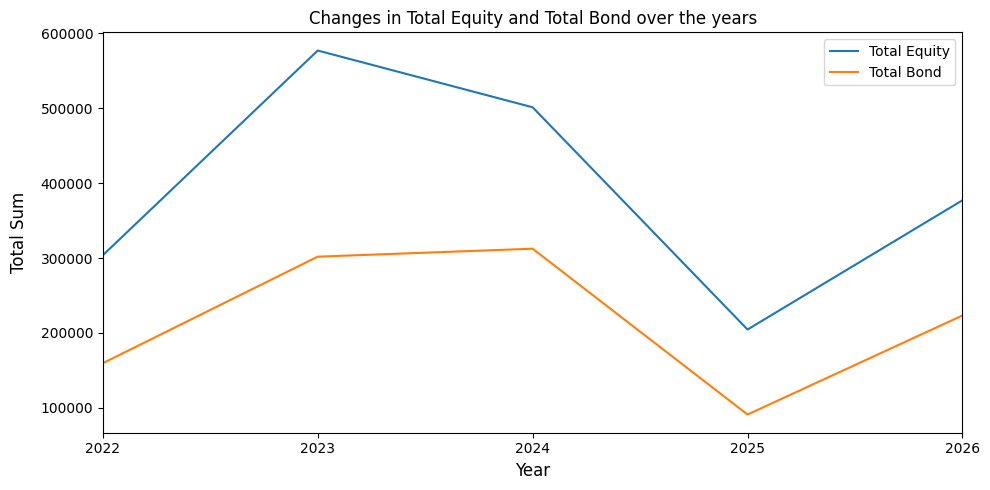

In [35]:
# i'll take columns `Total Equity` & `Total Bond` and show how these values changed through years using plot()
data = called_yearly[['Total Equity', 'Total Bond']]

gr = data.plot(
    figsize=(10, 5)
)
gr.set_xlabel('Year', fontsize=12)
gr.set_ylabel('Total Sum', fontsize=12, labelpad=9)
gr.set_title('Changes in Total Equity and Total Bond over the years')

plt.tight_layout()